In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
widebinary_raw = pd.read_parquet("../widebinaries/wdms_widebinaries.pqt")
widebinary_better = pd.read_parquet("../widebinaries/widebinary_fluxes.pqt")
widebinary_raw = widebinary_raw[widebinary_raw.wd_source_id.isin(widebinary_better["GaiaEDR3"])]

tyler_data = pd.read_csv("../widebinaries/data/tyler_wdwd.csv")
#tyler_data = tyler_data[tyler_data.source_id.isin(widebinary_better["GaiaEDR3"])]
list(tyler_data.keys())

/tmp/ipykernel_98644/4288502143.py:5: DtypeWarning: Columns (167,174,177) have mixed types. Specify dtype option on import or set low_memory=False.
  tyler_data = pd.read_csv("../widebinaries/data/tyler_wdwd.csv")


['System_Name',
 'source_id_spur',
 'fidelity_v1_spur',
 'solution_id',
 'source_id',
 'random_index',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'ra_dec_corr',
 'ra_parallax_corr',
 'ra_pmra_corr',
 'ra_pmdec_corr',
 'dec_parallax_corr',
 'dec_pmra_corr',
 'dec_pmdec_corr',
 'parallax_pmra_corr',
 'parallax_pmdec_corr',
 'pmra_pmdec_corr',
 'astrometric_n_obs_al',
 'astrometric_n_obs_ac',
 'astrometric_n_good_obs_al',
 'astrometric_n_bad_obs_al',
 'astrometric_gof_al',
 'astrometric_chi2_al',
 'astrometric_excess_noise',
 'astrometric_excess_noise_sig',
 'astrometric_params_solved',
 'astrometric_primary_flag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'pseudocolour_error',
 'ra_pseudocolour_corr',
 'dec_pseudocolour_corr',
 'parallax_pseudocolour_corr',
 'pmra_pseudocolour_corr',
 'pmdec_pseudocolour_corr',
 'astrometric_matched_transits',
 'visibility_

In [15]:
tyler_data["System_ID"] = tyler_data["System_Name"].str[:-1]
primary = tyler_data["System_Name"].str[-1] == "A"
secondary = tyler_data["System_Name"].str[-1] == "B"


wdwd_systems_tyler = pd.merge(tyler_data[primary], tyler_data[secondary], on="System_ID", suffixes=("_pri", "_sec"))
wdwd_systems_tyler[["source_id_pri", "source_id_sec"]]

,source_id_pri,source_id_sec
0,6069049064270285568,6069049068562148736
1,4299762403650843392,4299762438012187264
2,4252048516799737728,4251609055727677440
3,3051617488359028096,3051617492658946944
4,454793399779350016,454793399779351552
...,...,...
1586,3682458814461982592,3682458986260679808
1587,1829120747684239104,1829120747684237312
1588,4315701821885383808,4315701821873535488
1589,1141846540594232192,1141846540594232064


In [16]:
np.all(wdwd_systems_tyler["source_id_pri"] == wdwd_systems_tyler["source_id_sec"])

np.False_

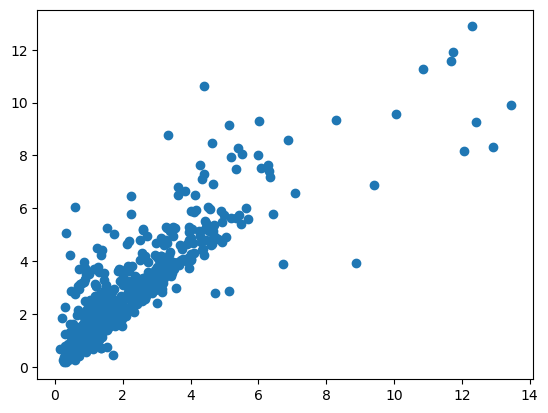

In [19]:
mask = (wdwd_systems_tyler["MassH_pri"] > 0.63) & (wdwd_systems_tyler["MassH_sec"] > 0.63)
plt.scatter(wdwd_systems_tyler.loc[mask,"tot_age_MESA_IFMR_pri"],
            wdwd_systems_tyler.loc[mask,"tot_age_MESA_IFMR_sec"])

In [ ]:
merge = pd.merge(tyler_data, widebinary_better, left_on="source_id", right_on="gaia_dr3_source_id")

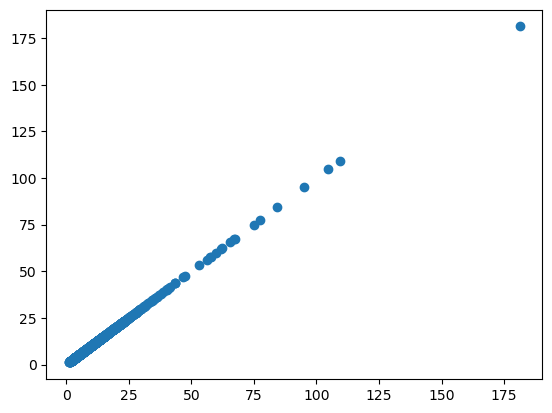

In [12]:
plt.scatter(merge["wtd_par"], merge["my_wtd_plx"])